# Finalized Figures

Publication- and presentation-ready figures for PEC (phase error correction).
Each figure is built up in stages for slide animation.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats as sp_stats

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "PEC_quantitative_analysis"
DATA_CSV = NOTEBOOK_DIR / "consolidated.csv"
ERROR_CSV = NOTEBOOK_DIR / "error_metrics.csv"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

COLORS = {"uncorrected": "white", "cnn": "#1f77b4", "manual": "#888888"}
LABELS = {"uncorrected": "Uncorrected", "cnn": "CNN Corrected", "manual": "Manual"}
VESSELS = ["Ao", "PA"]
VESSEL_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 17,
    "figure.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

data = pd.read_csv(DATA_CSV)
compared = pd.read_csv(ERROR_CSV)

print(f"{len(data)} rows  |  {data['patient'].nunique()} patients  |  "
      f"vessels: {sorted(data['vessel'].unique())}  |  methods: {sorted(data['method'].unique())}")
print(f"{len(compared)} comparison rows")

90 rows  |  15 patients  |  vessels: ['Ao', 'PA']  |  methods: ['cnn', 'manual', 'uncorrected']
60 comparison rows


In [9]:
flow_pivot = data.pivot_table(
    index=["patient", "vessel"],
    columns="method",
    values="flow",
).reset_index()

flow_pivot["cnn_error"] = flow_pivot["cnn"] - flow_pivot["manual"]
flow_pivot["uncorrected_error"] = flow_pivot["uncorrected"] - flow_pivot["manual"]
flow_pivot["cnn_abs_error"] = flow_pivot["cnn_error"].abs()
flow_pivot["uncorrected_abs_error"] = flow_pivot["uncorrected_error"].abs()

flow_pivot = flow_pivot.dropna(subset=["manual"])

def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stat_rows = []
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])
    n = len(vp)

    for method in ["cnn", "uncorrected"]:
        diff = vp[f"{method}_error"].values
        r, r_p = sp_stats.pearsonr(vp[method].values, vp["manual"].values)
        stat_rows.append({
            "vessel": vessel,
            "comparison": f"{LABELS[method]} vs Manual",
            "n": n,
            "bias": diff.mean(),
            "bias_std": diff.std(),
            "loa_lower": diff.mean() - 1.96 * diff.std(),
            "loa_upper": diff.mean() + 1.96 * diff.std(),
            "pearson_r": r,
            "pearson_p": r_p,
        })

    cnn_ae = vp["cnn_abs_error"].values
    unc_ae = vp["uncorrected_abs_error"].values
    error_diff = unc_ae - cnn_ae
    _, w_p = sp_stats.wilcoxon(error_diff)
    stat_rows.append({
        "vessel": vessel,
        "comparison": "Error reduction (|Uncorr| − |CNN|)",
        "n": n,
        "bias": error_diff.mean(),
        "bias_std": error_diff.std(),
        "wilcoxon_p": w_p,
        "wilcoxon_sig": _sig(w_p),
    })

stats_results = pd.DataFrame(stat_rows)
print(f"{len(flow_pivot)} patient-vessel pairs with complete data")

29 patient-vessel pairs with complete data


## Figure 1a: Bland-Altman — Agreement with Manual Correction

Difference (method − manual) vs. mean of the two, for both CNN and Uncorrected.
Rows = vessels (Ao, PA), columns = methods (Uncorrected, CNN Corrected).

Build-up stages:
1. Uncorrected only (left column)
2. Full figure (Uncorrected + CNN Corrected)

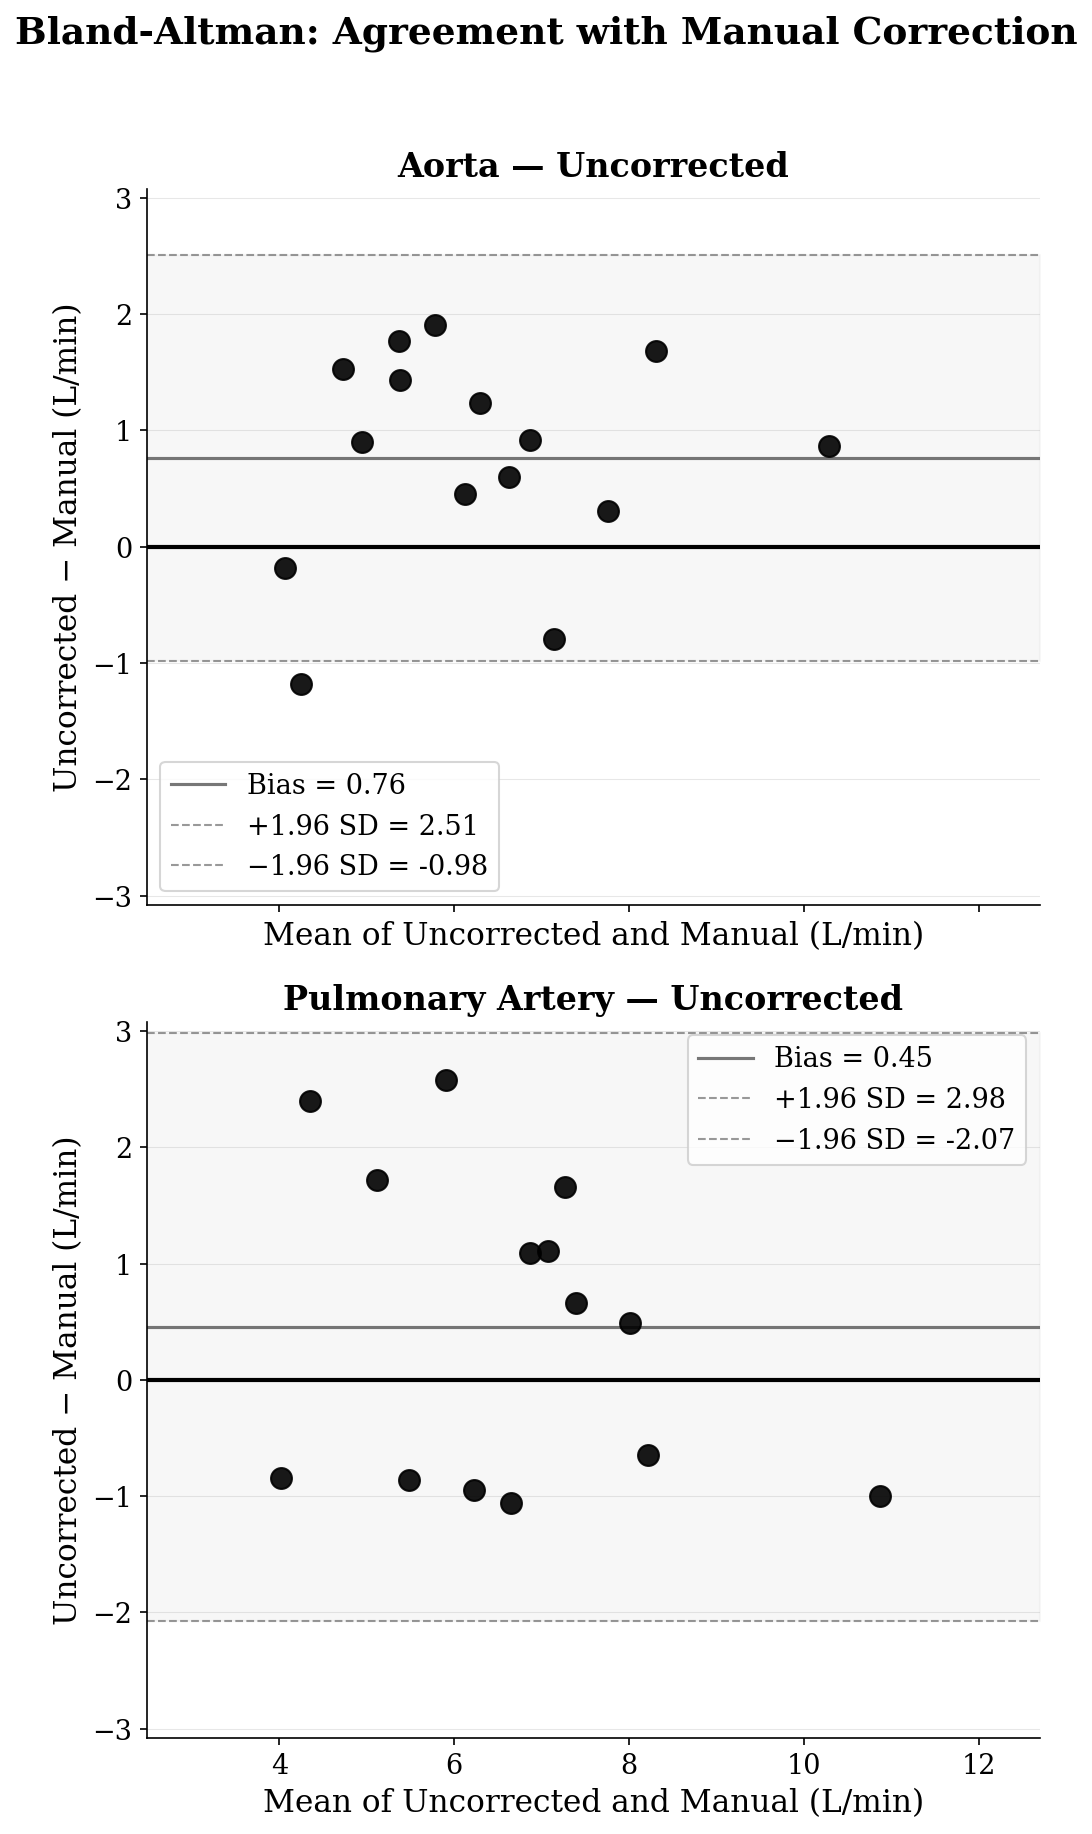

Saved: fig1a_bland_altman_uncorrected.png


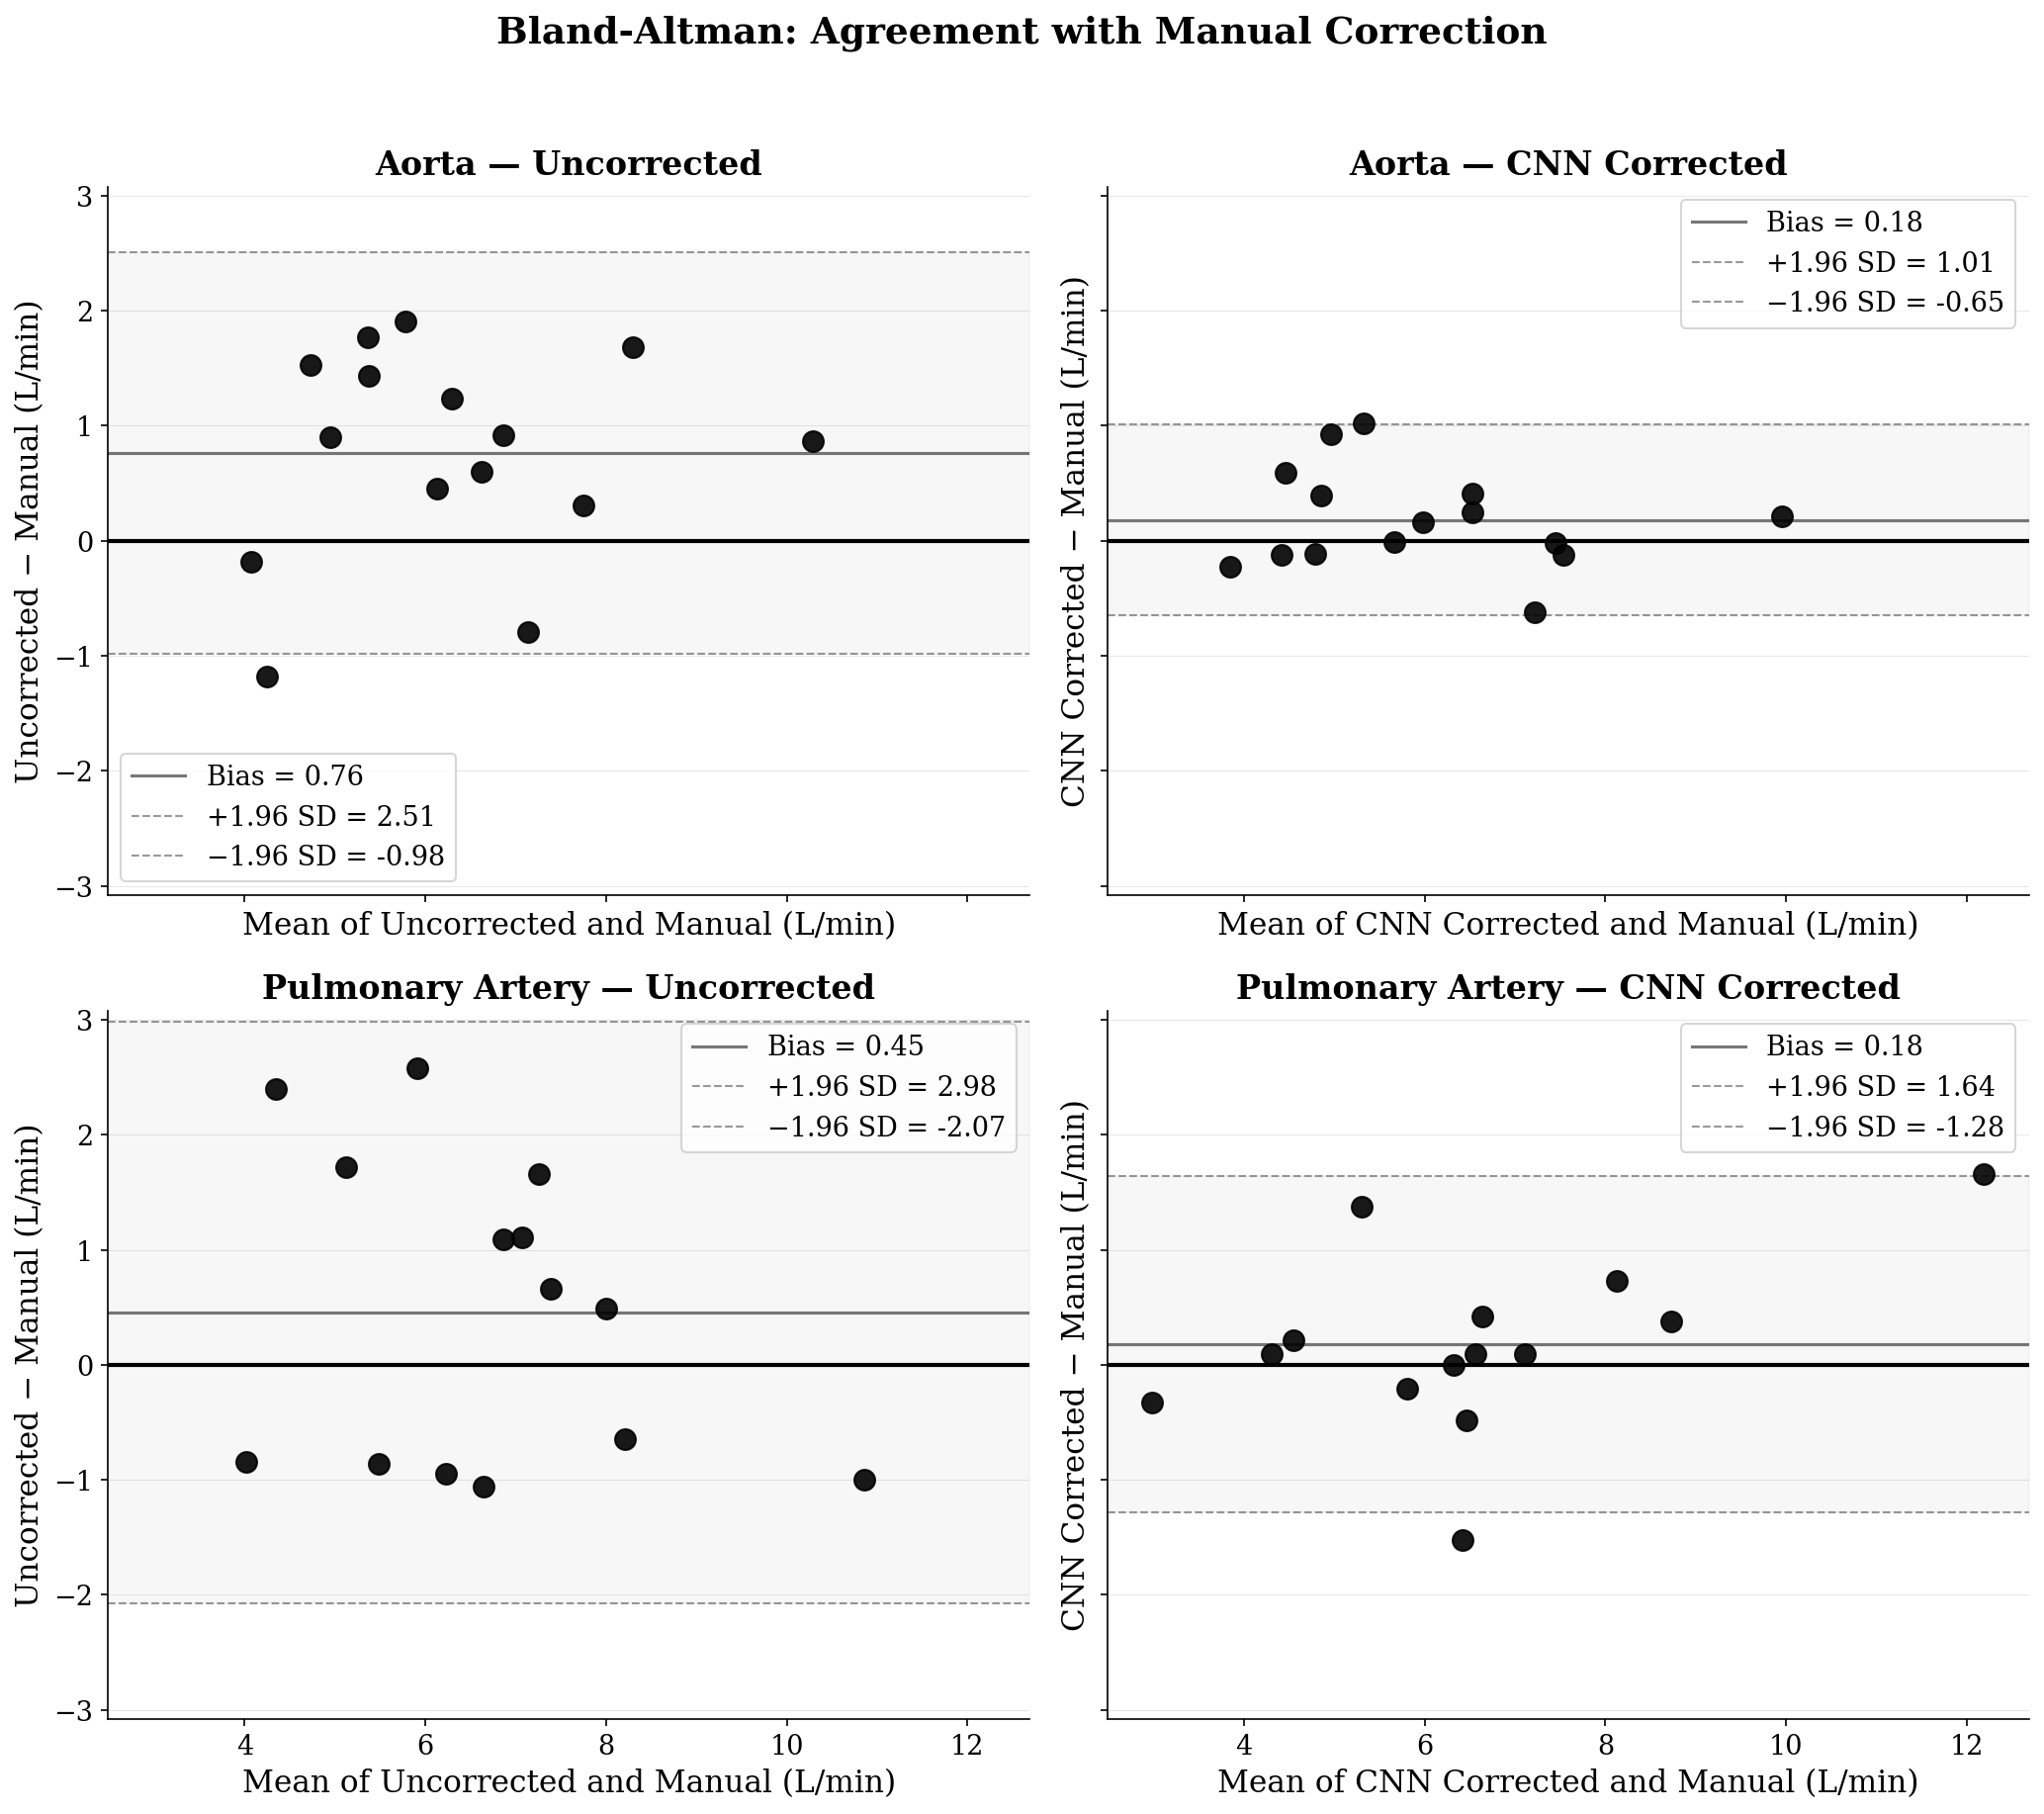

Saved: fig1a_bland_altman_full.png


In [10]:
def bland_altman(ax, method_vals, ref_vals, color, label, x_lo=None, x_hi=None,
                 point_color="black", edge_color=None):
    """Draw a Bland-Altman plot on the given axes."""
    mean_vals = (method_vals + ref_vals) / 2
    diff_vals = method_vals - ref_vals

    bias = diff_vals.mean()
    sd = diff_vals.std()
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    ec = edge_color if edge_color is not None else point_color
    ax.scatter(mean_vals, diff_vals, c=point_color, edgecolors=ec, s=100, alpha=0.9, zorder=3)
    ax.axhline(bias, color="#555", linewidth=1.5, linestyle="-", alpha=0.8,
               label=f"Bias = {bias:.2f}")
    ax.axhline(loa_upper, color="#555", linewidth=1.0, linestyle="--", alpha=0.6,
               label=f"+1.96 SD = {loa_upper:.2f}")
    ax.axhline(loa_lower, color="#555", linewidth=1.0, linestyle="--", alpha=0.6,
               label=f"\u22121.96 SD = {loa_lower:.2f}")
    ax.axhline(0, color="black", linewidth=2.0, alpha=1.0)
    if x_lo is not None and x_hi is not None:
        ax.fill_between([x_lo, x_hi], loa_lower, loa_upper, color="#cccccc", alpha=0.15)

    ax.set_xlabel(f"Mean of {label} and Manual (L/min)", fontsize=15)
    ax.set_ylabel(f"{label} \u2212 Manual (L/min)", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, loc="best")

# Precompute shared axis limits
all_means, all_diffs = [], []
ba_data = {}
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])
    ba_data[vessel] = vp
    for method in ["cnn", "uncorrected"]:
        m = (vp[method].values + vp["manual"].values) / 2
        d = vp[method].values - vp["manual"].values
        all_means.extend(m)
        all_diffs.extend(d)

x_lo, x_hi = min(all_means) - 0.5, max(all_means) + 0.5
y_abs_max = max(abs(min(all_diffs)), abs(max(all_diffs))) + 0.5
y_lo, y_hi = -y_abs_max, y_abs_max

STAGES = [
    ("uncorrected", True,  False),
    ("full",        True,  True),
]

for stage_name, show_uncorr, show_cnn in STAGES:
    ncols = 2 if show_cnn else 1
    fig, axes = plt.subplots(len(VESSELS), ncols, figsize=(7 * ncols, 6 * len(VESSELS)),
                             sharex=True, sharey=True, squeeze=False)

    for i, vessel in enumerate(VESSELS):
        vp = ba_data[vessel]

        n_vessel = len(vp)
        if show_uncorr:
            bland_altman(axes[i, 0], vp["uncorrected"].values, vp["manual"].values,
                         COLORS["uncorrected"], "Uncorrected", x_lo, x_hi)
            axes[i, 0].set_title(f"{VESSEL_LABELS[vessel]} \u2014 Uncorrected", fontweight="bold", fontsize=16)

        if show_cnn:
            bland_altman(axes[i, 1], vp["cnn"].values, vp["manual"].values,
                         COLORS["cnn"], "CNN Corrected", x_lo, x_hi)
            axes[i, 1].set_title(f"{VESSEL_LABELS[vessel]} \u2014 CNN Corrected", fontweight="bold", fontsize=16)

    axes[0, 0].set_xlim(x_lo, x_hi)
    axes[0, 0].set_ylim(y_lo, y_hi)

    fig.suptitle("Bland-Altman: Agreement with Manual Correction",
                 fontsize=18, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig1a_bland_altman_{stage_name}.png",
                bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: fig1a_bland_altman_{stage_name}.png")

## Figure 1b: Correlation with Manual Correction (Ground Truth)

CNN-corrected and Uncorrected flow vs. Manual. Perfect agreement = identity line.
Rows = vessels (Ao, PA), columns = methods (Uncorrected, CNN Corrected).

Build-up stages:
1. Uncorrected only (left column)
2. Full figure (Uncorrected + CNN Corrected)

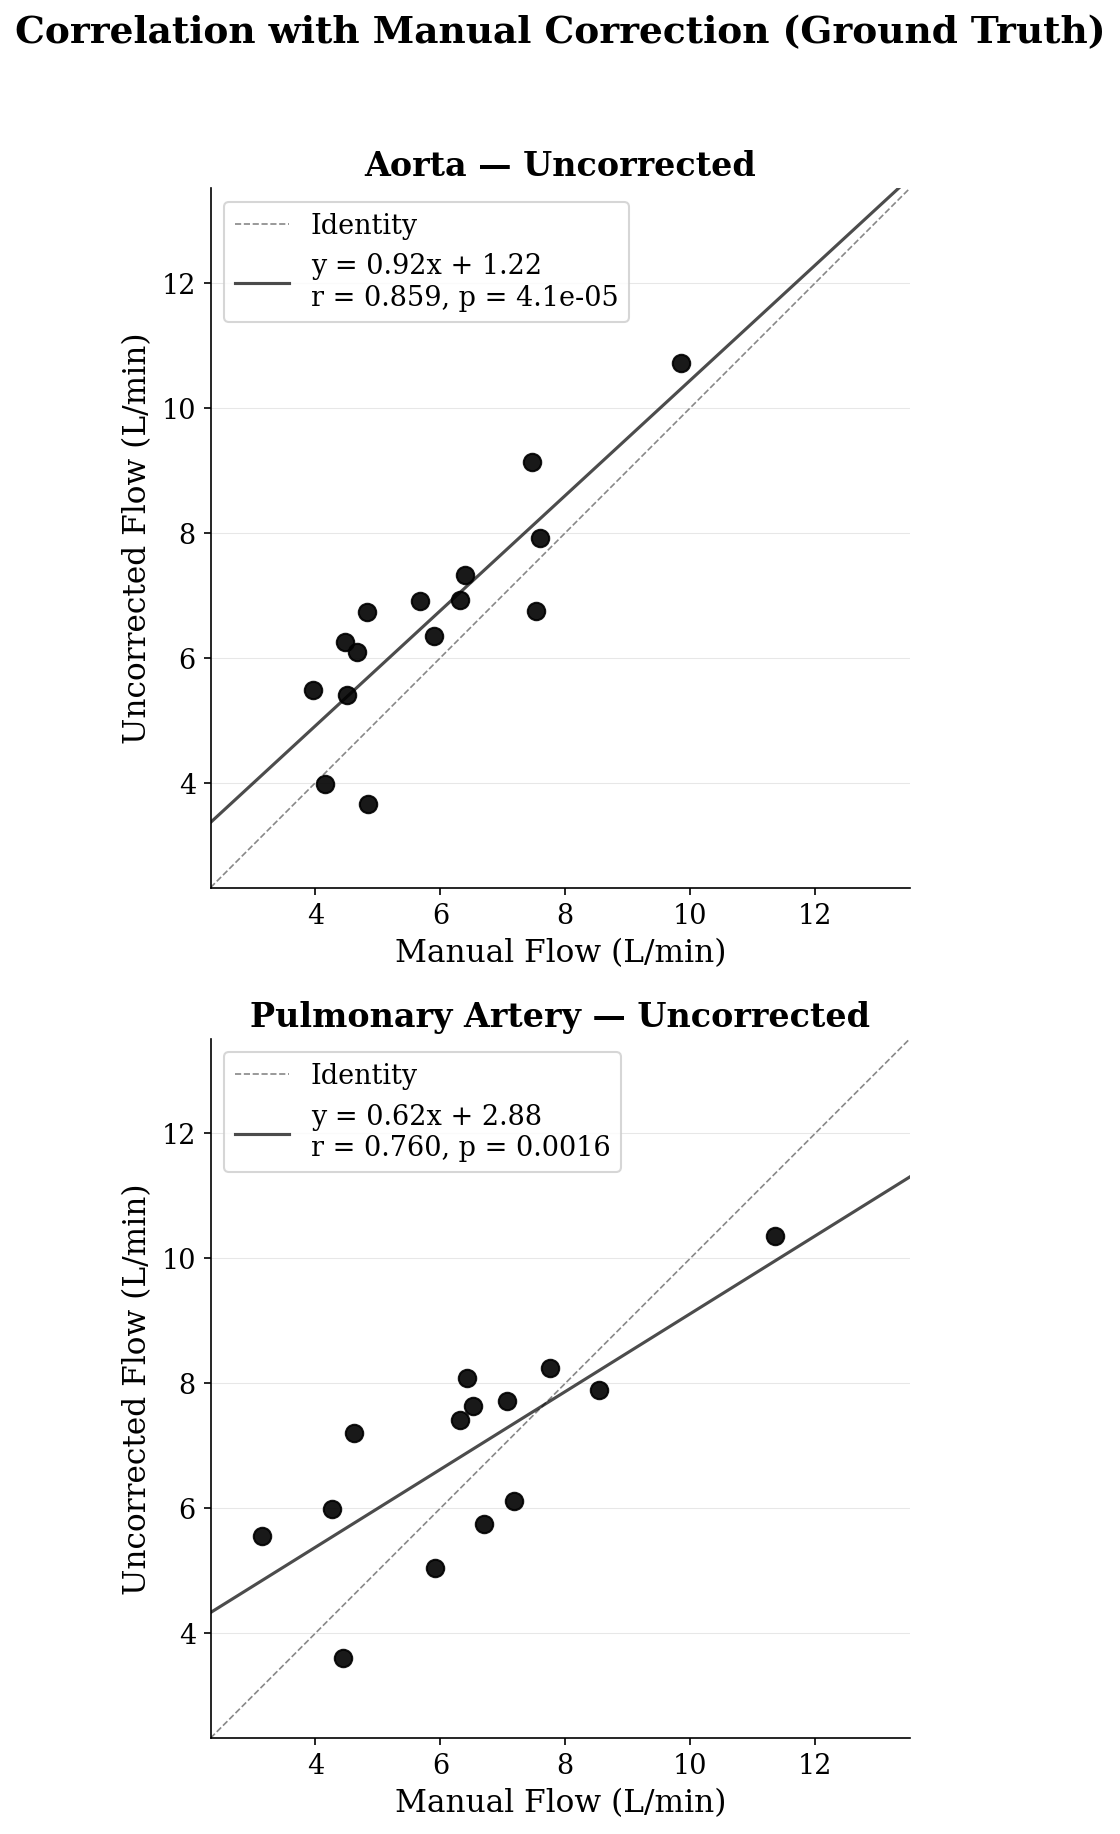

Saved: fig1b_correlation_uncorrected.png


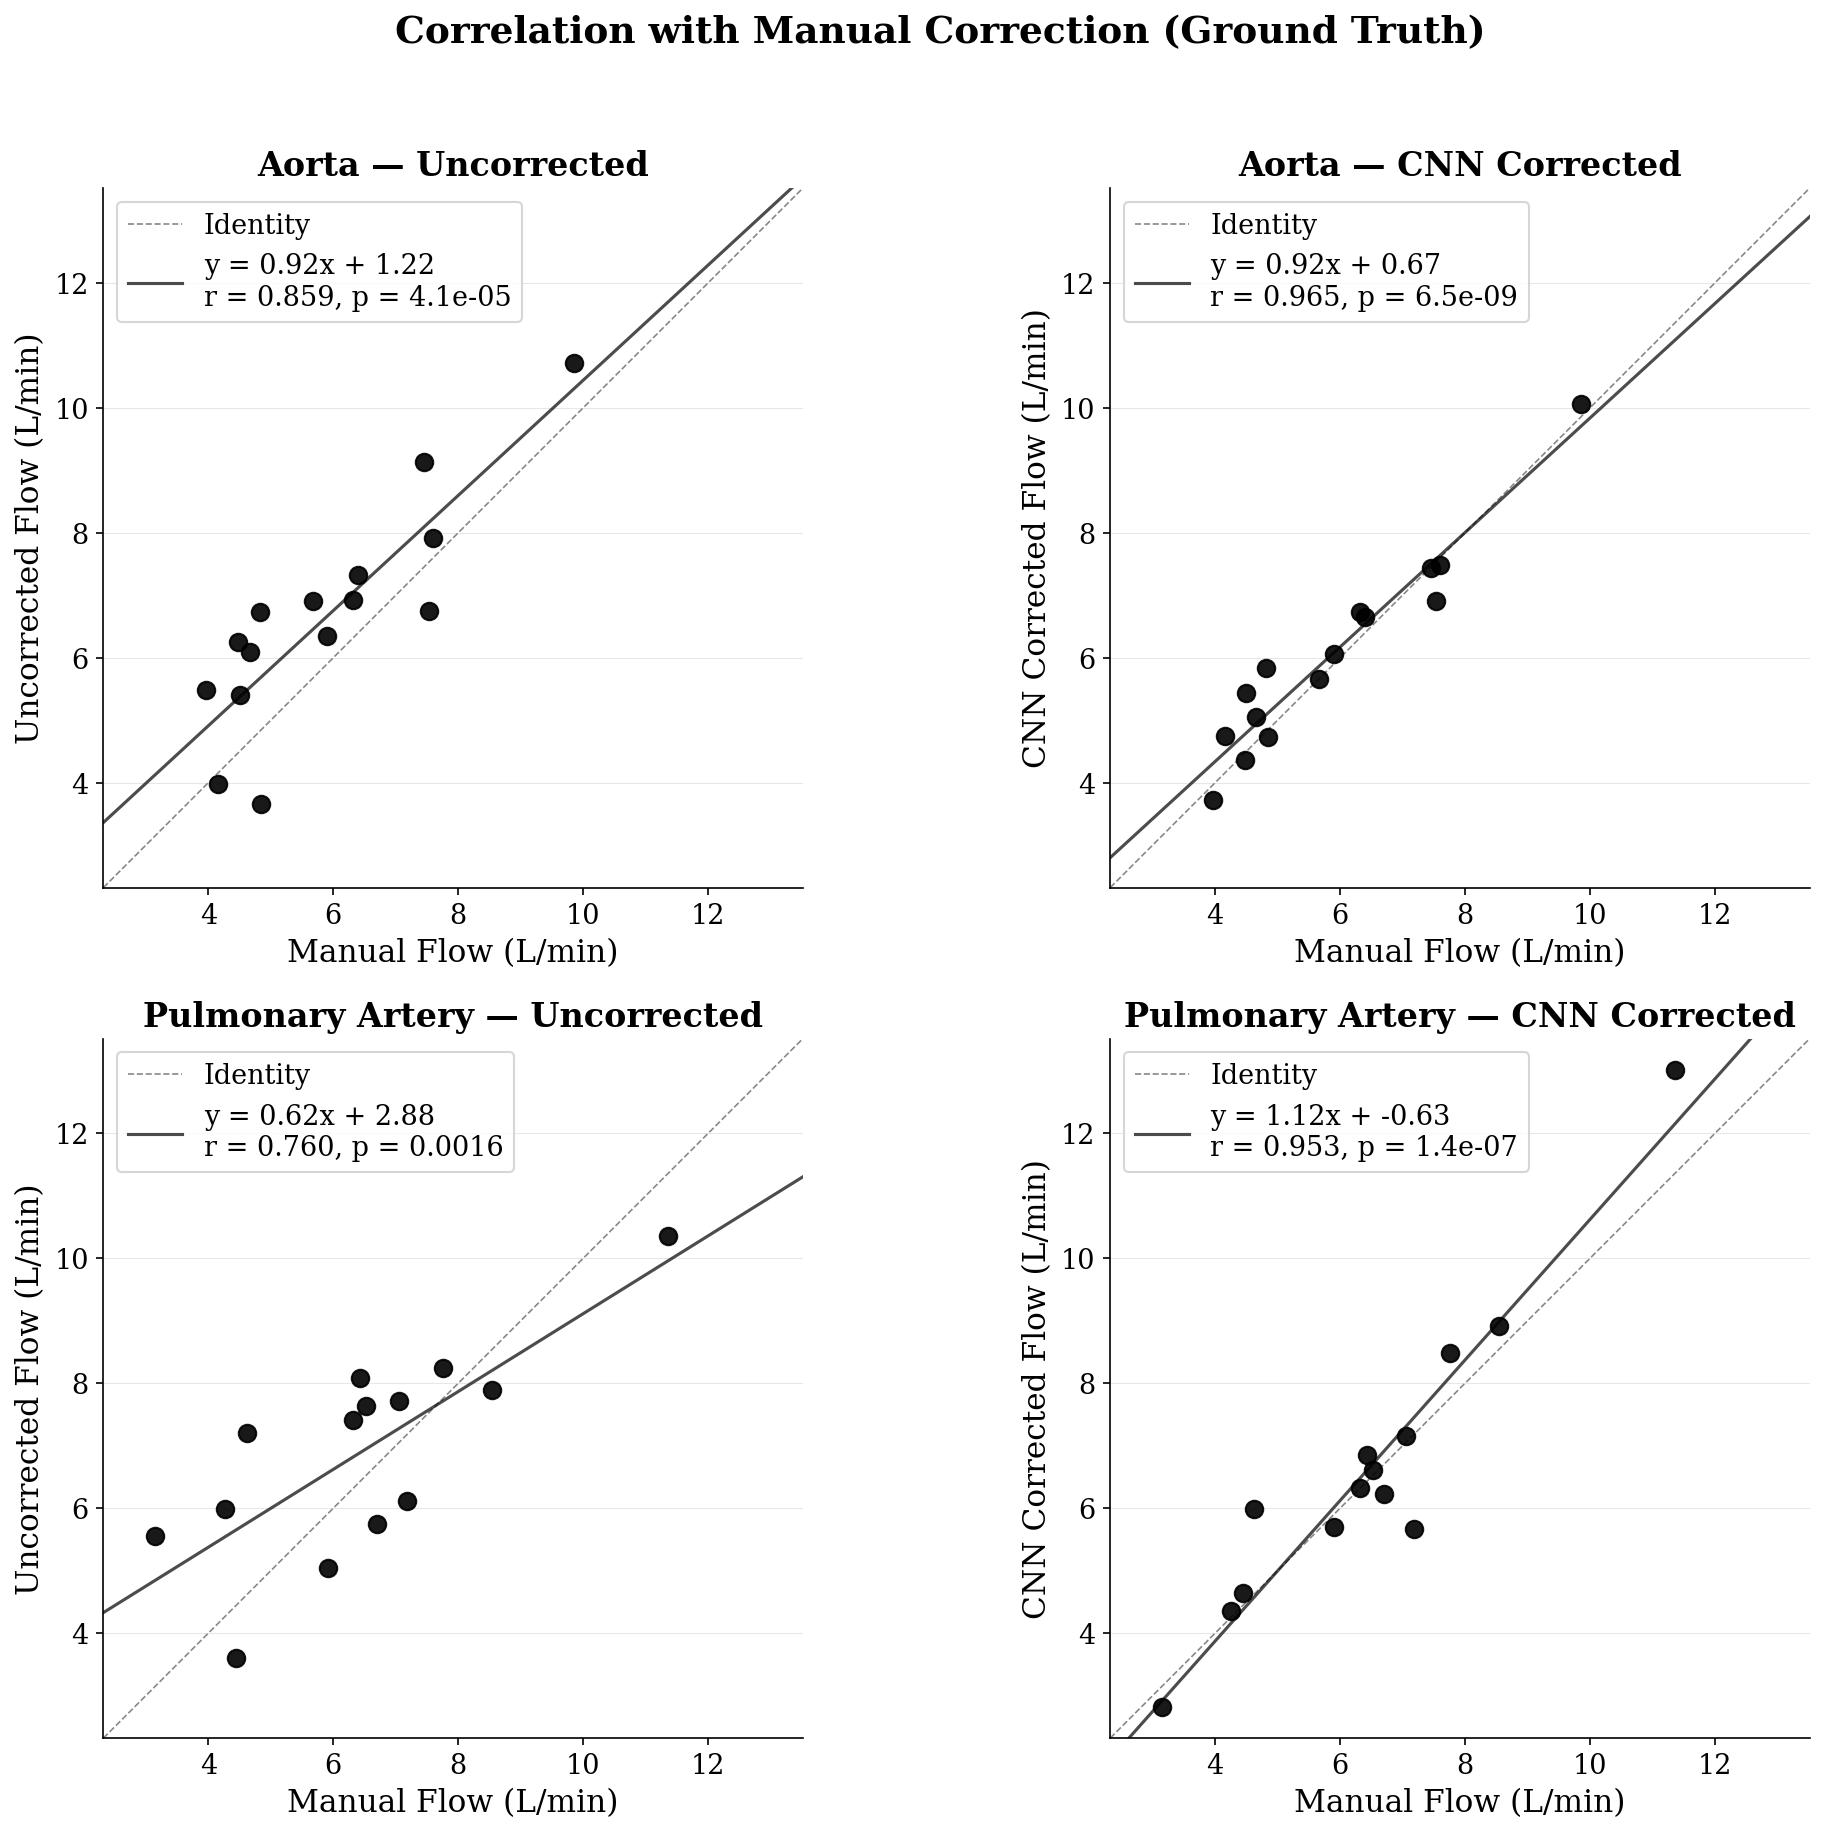

Saved: fig1b_correlation_full.png


In [11]:
# Precompute shared axis limits across all panels
all_flow = []
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])
    all_flow.extend(vp["manual"].values)
    all_flow.extend(vp["cnn"].values)
    all_flow.extend(vp["uncorrected"].values)
corr_lims = [min(all_flow) - 0.5, max(all_flow) + 0.5]

STAGES = [
    ("uncorrected", True,  False),
    ("full",        True,  True),
]

METHODS_ORDER = [("uncorrected", 0), ("cnn", 1)]

for stage_name, show_uncorr, show_cnn in STAGES:
    ncols = 2 if show_cnn else 1
    fig, axes = plt.subplots(len(VESSELS), ncols, figsize=(7 * ncols, 6 * len(VESSELS)),
                             squeeze=False)

    methods_to_show = []
    if show_uncorr:
        methods_to_show.append(("uncorrected", 0))
    if show_cnn:
        methods_to_show.append(("cnn", 1))

    for i, vessel in enumerate(VESSELS):
        vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["manual", "cnn", "uncorrected"])

        for method, col_idx in methods_to_show:
            ax = axes[i, col_idx]
            x = vp["manual"].values
            y = vp[method].values

            ax.scatter(x, y, c="black", edgecolors="black", s=70, alpha=0.9, zorder=3)

            ax.plot(corr_lims, corr_lims, "--", color="#888", linewidth=0.8, label="Identity")

            slope, intercept, r, p, se = sp_stats.linregress(x, y)
            xfit = np.linspace(corr_lims[0], corr_lims[1], 100)
            p_str = f"{p:.1e}" if p < 0.0001 else f"{p:.4f}"
            ax.plot(xfit, slope * xfit + intercept, "-", color="black",
                    linewidth=1.5, alpha=0.7,
                    label=f"y = {slope:.2f}x + {intercept:.2f}\nr = {r:.3f}, p = {p_str}")

            ax.set_xlim(corr_lims)
            ax.set_ylim(corr_lims)
            ax.set_aspect("equal")
            ax.set_xlabel("Manual Flow (L/min)", fontsize=15)
            ax.set_ylabel(f"{LABELS[method]} Flow (L/min)", fontsize=15)
            ax.set_title(f"{VESSEL_LABELS[vessel]} \u2014 {LABELS[method]}", fontweight="bold", fontsize=16)
            ax.tick_params(labelsize=13)
            ax.legend(fontsize=13, loc="upper left")

    fig.suptitle("Correlation with Manual Correction (Ground Truth)",
                 fontsize=18, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig1b_correlation_{stage_name}.png",
                bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: fig1b_correlation_{stage_name}.png")

## Figure 1c: Per-Vessel Bland-Altman + Correlation

One 2×2 figure per vessel (Aorta, Pulmonary Artery):

- **Row 1:** Bland-Altman (difference vs. mean) — Uncorrected vs. manual | CNN-corrected vs. manual
- **Row 2:** Correlation (method flow vs. manual flow) — same columns
- **Colors:** Uncorrected = black; CNN corrected = blue

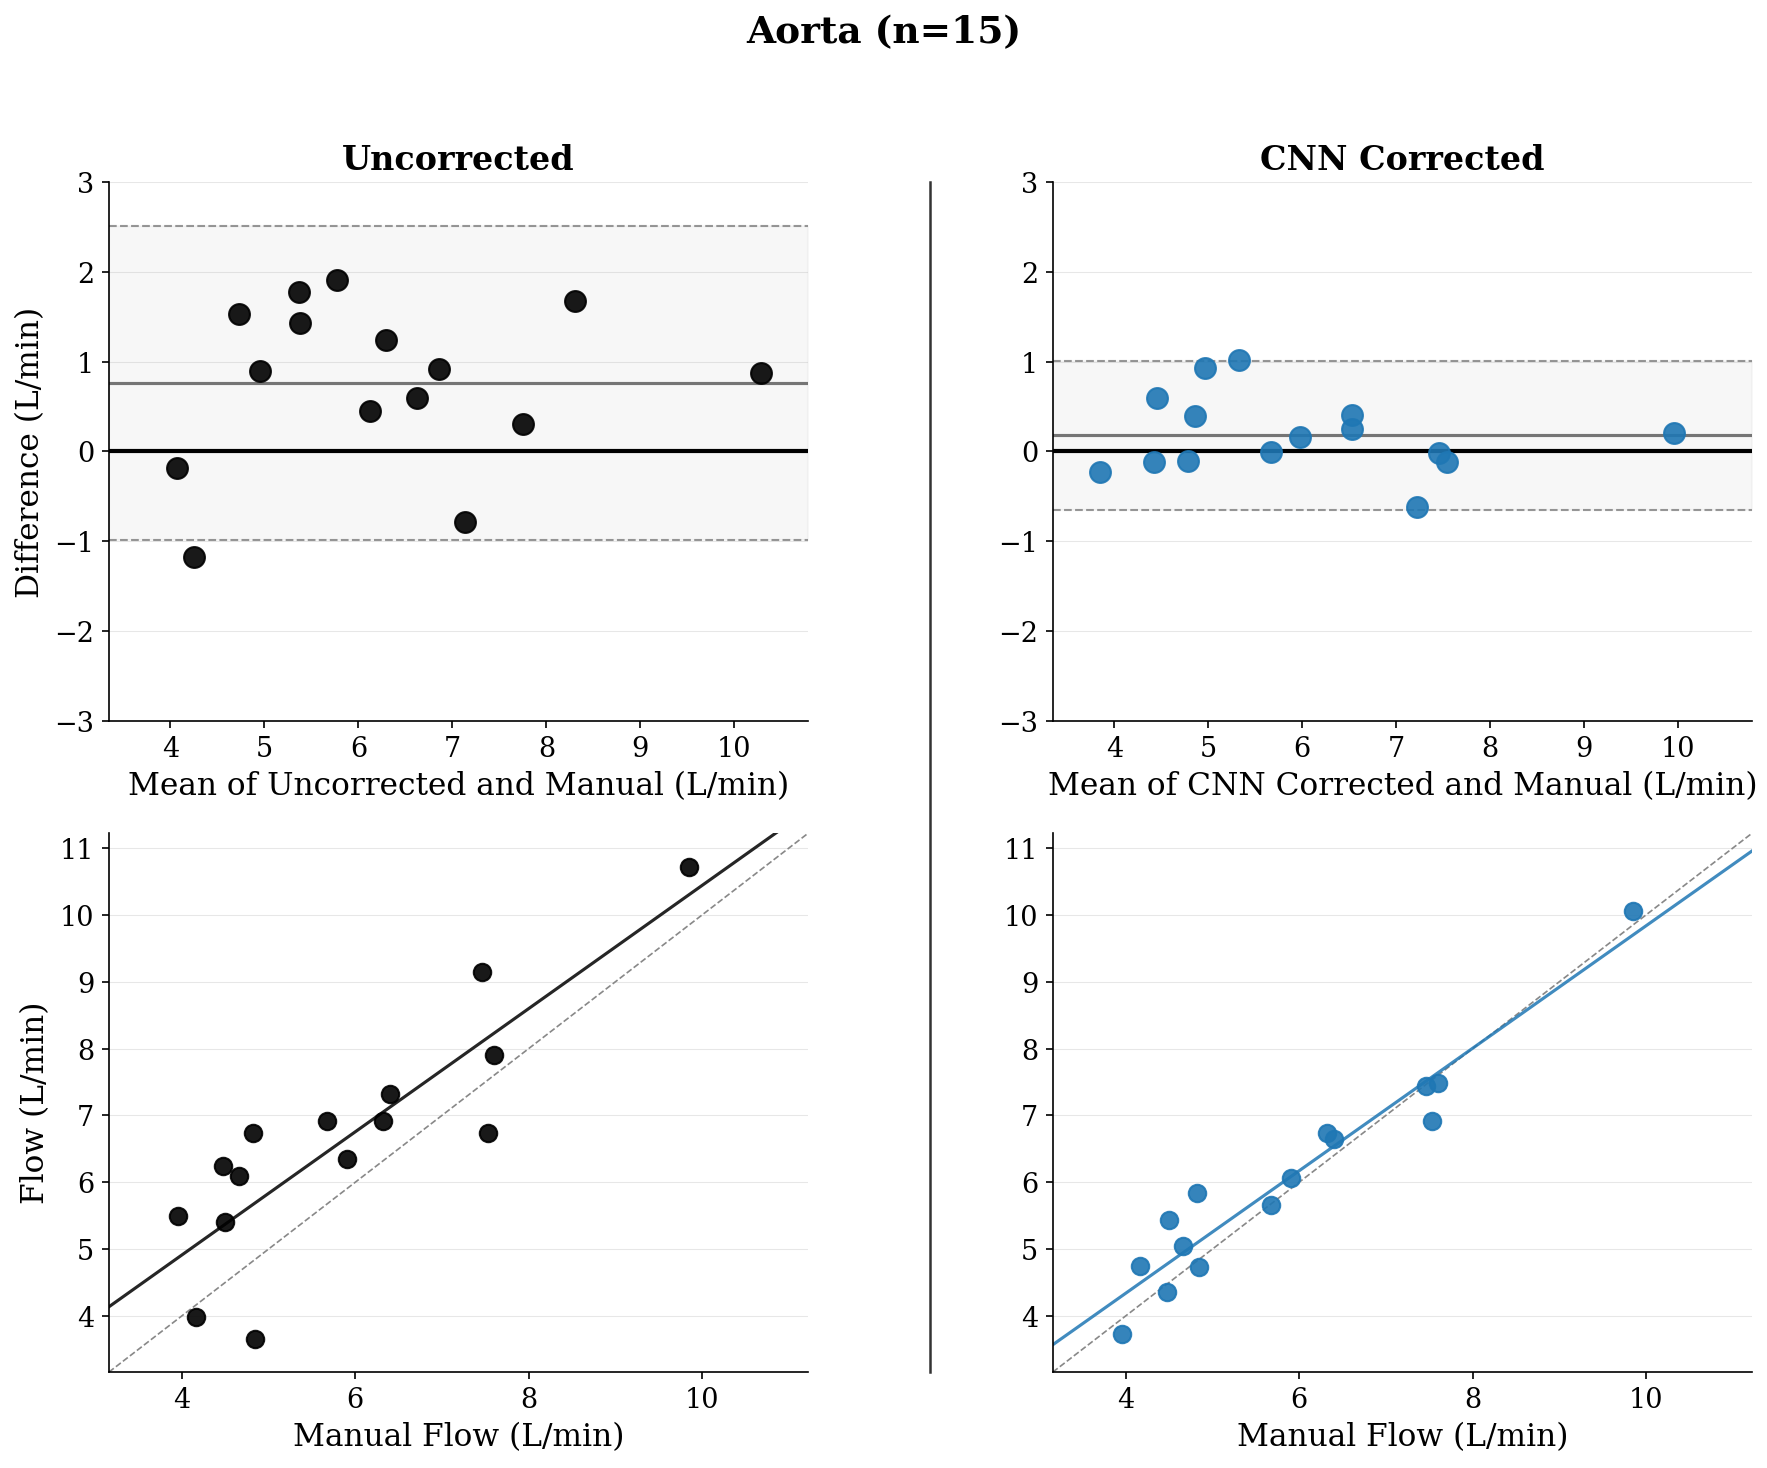

Saved: fig1c_ao_bland_altman_regression.png


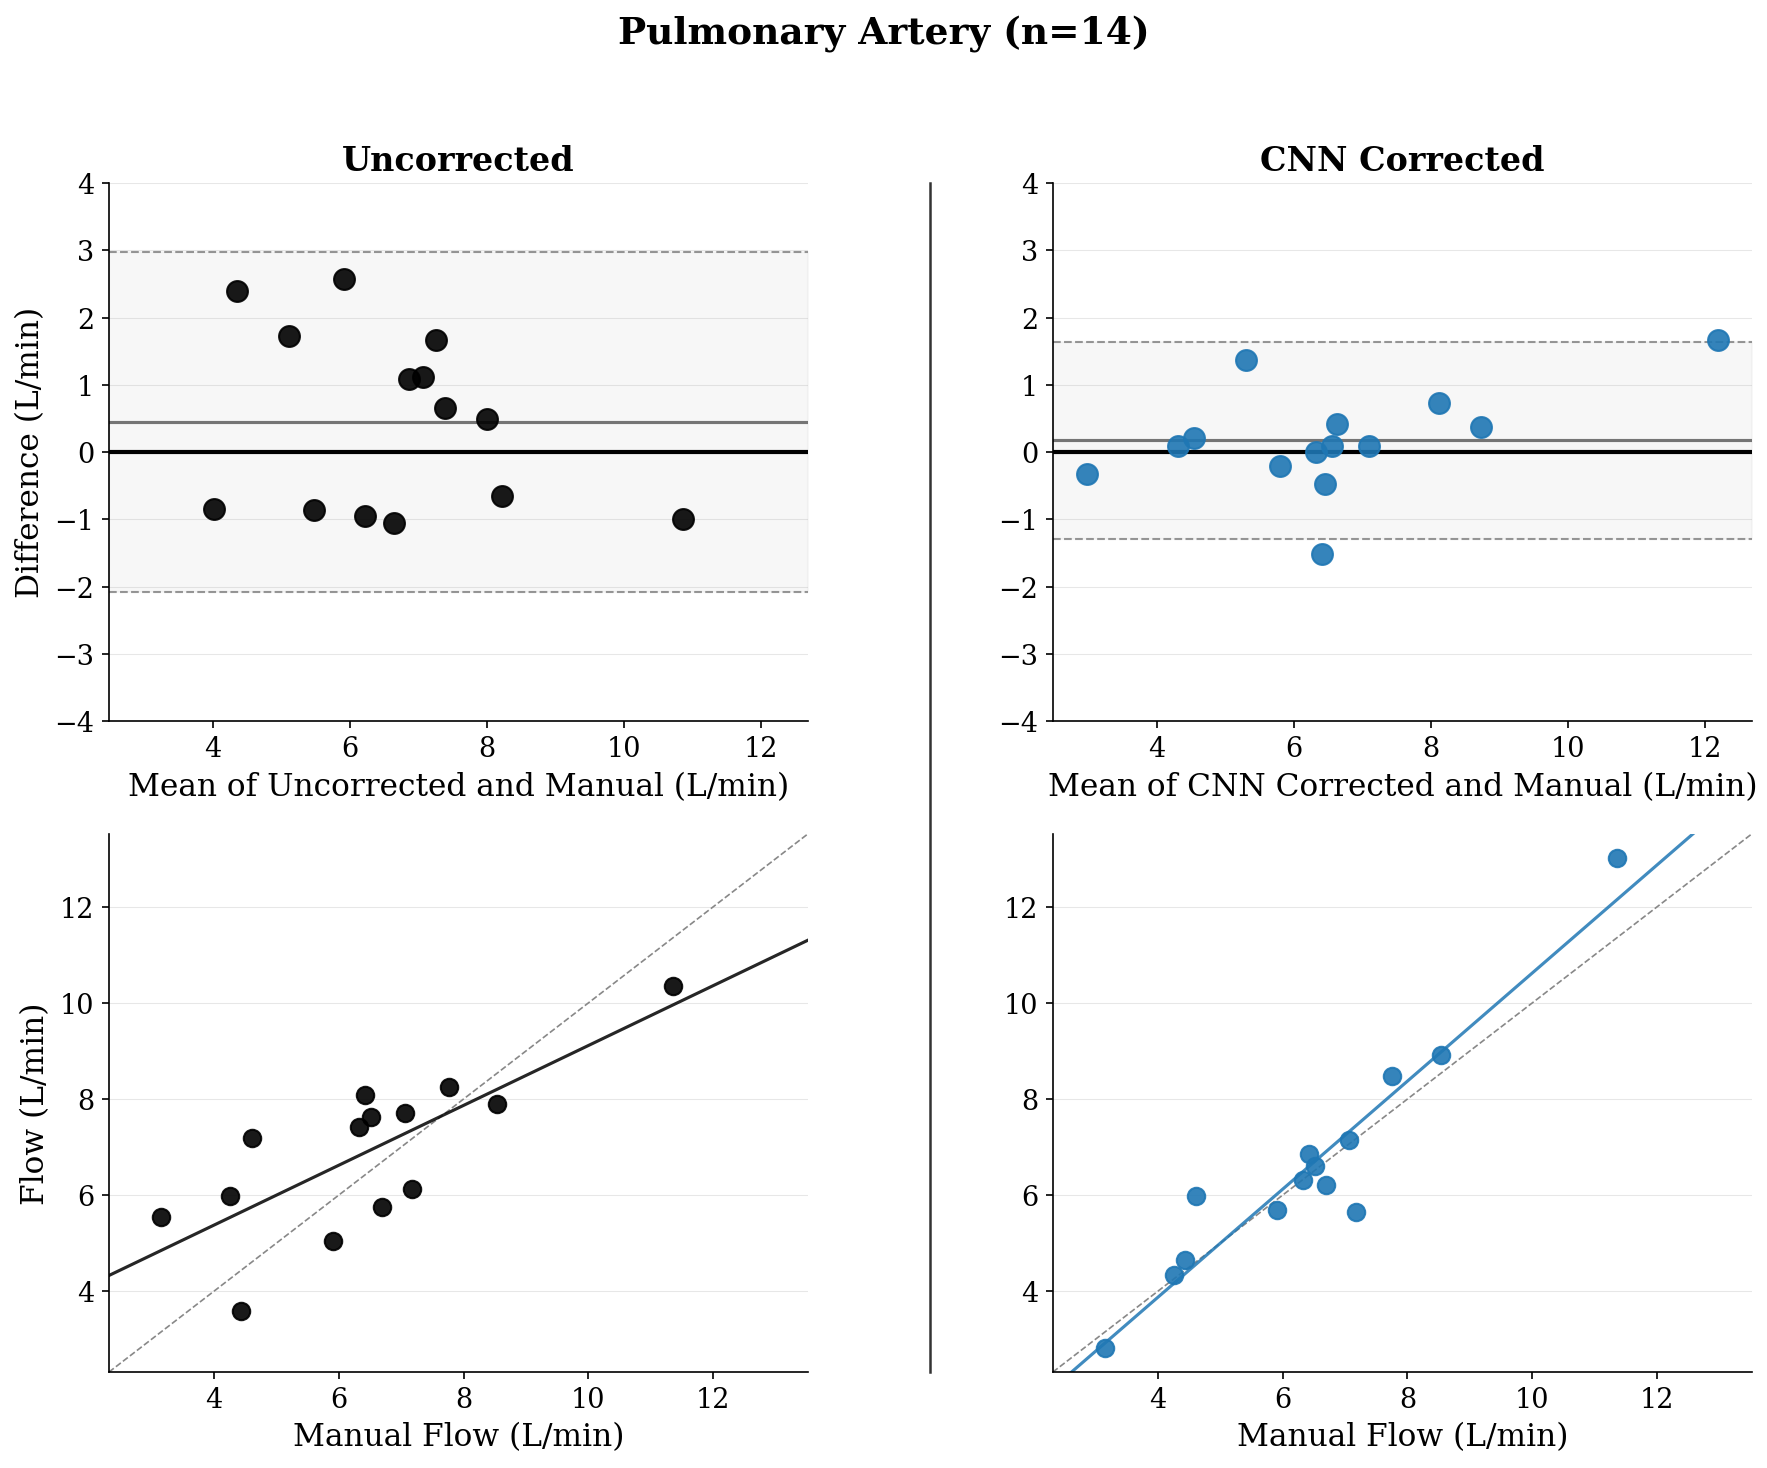

Saved: fig1c_pa_bland_altman_regression.png


In [12]:
FIG1C_UNCORR = "black"
FIG1C_CNN = "#1f77b4"

for vessel in VESSELS:
    vp = ba_data[vessel]

    # Vessel-specific limits for Bland-Altman
    v_means, v_diffs = [], []
    for method in ["cnn", "uncorrected"]:
        m = (vp[method].values + vp["manual"].values) / 2
        d = vp[method].values - vp["manual"].values
        v_means.extend(m)
        v_diffs.extend(d)
    v_x_lo, v_x_hi = min(v_means) - 0.5, max(v_means) + 0.5
    v_y_abs = max(max(abs(min(v_diffs)), abs(max(v_diffs))) + 1.0, 2.5)
    v_y_abs = np.ceil(v_y_abs * 2) / 2
    v_y_lo, v_y_hi = -v_y_abs, v_y_abs

    # Vessel-specific limits for regression
    v_flow = []
    for method in ["manual", "cnn", "uncorrected"]:
        v_flow.extend(vp[method].values)
    v_corr_lims = [min(v_flow) - 0.5, max(v_flow) + 0.5]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].sharey(axes[0, 1])
    axes[1, 0].sharey(axes[1, 1])

    # Top row: Bland-Altman (no legend); uncorrected = black, CNN = blue
    bland_altman(axes[0, 0], vp["uncorrected"].values, vp["manual"].values,
                 FIG1C_UNCORR, "Uncorrected", v_x_lo, v_x_hi,
                 point_color=FIG1C_UNCORR, edge_color=FIG1C_UNCORR)
    axes[0, 0].legend().set_visible(False)
    axes[0, 0].set_title("Uncorrected", fontweight="bold", fontsize=16)
    bland_altman(axes[0, 1], vp["cnn"].values, vp["manual"].values,
                 FIG1C_CNN, "CNN Corrected", v_x_lo, v_x_hi,
                 point_color=FIG1C_CNN, edge_color=FIG1C_CNN)
    axes[0, 1].legend().set_visible(False)
    axes[0, 1].set_ylabel("")
    axes[0, 1].set_title("CNN Corrected", fontweight="bold", fontsize=16)
    axes[0, 0].set_xlim(v_x_lo, v_x_hi)
    axes[0, 1].set_xlim(v_x_lo, v_x_hi)
    axes[0, 0].set_ylim(v_y_lo, v_y_hi)

    # Bottom row: Correlation (no stats, no titles); line color matches column
    for col_idx, method in enumerate(["uncorrected", "cnn"]):
        ax = axes[1, col_idx]
        x = vp["manual"].values
        y = vp[method].values
        line_c = FIG1C_UNCORR if method == "uncorrected" else FIG1C_CNN
        ax.scatter(x, y, c=line_c, edgecolors=line_c, s=70, alpha=0.9, zorder=3)
        ax.plot(v_corr_lims, v_corr_lims, "--", color="#888", linewidth=0.8)
        slope, intercept, r, p, se = sp_stats.linregress(x, y)
        xfit = np.linspace(v_corr_lims[0], v_corr_lims[1], 100)
        ax.plot(xfit, slope * xfit + intercept, "-", color=line_c, linewidth=1.5, alpha=0.85)
        ax.set_xlim(v_corr_lims)
        ax.set_ylim(v_corr_lims)
        ax.set_xlabel("Manual Flow (L/min)", fontsize=15)
        ax.set_ylabel(f"{LABELS[method]} Flow (L/min)" if col_idx == 0 else "", fontsize=15)
        ax.tick_params(labelsize=13)

    axes[0, 0].set_ylabel("Difference (L/min)", fontsize=15)
    axes[1, 0].set_ylabel("Flow (L/min)", fontsize=15)
    fig.suptitle(f"{VESSEL_LABELS[vessel]} (n={len(vp)})",
                 fontsize=18, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.subplots_adjust(wspace=0.35)

    # Vertical separator: centered in the gap between columns
    from matplotlib.lines import Line2D
    pos_left = axes[0, 0].get_position()
    pos_right = axes[0, 1].get_position()
    gap = pos_right.x0 - pos_left.x1
    x_sep = pos_left.x1 + gap * 0.5
    y_bot = axes[1, 0].get_position().y0
    y_top = axes[0, 0].get_position().y1
    fig.add_artist(Line2D([x_sep, x_sep], [y_bot, y_top], transform=fig.transFigure,
                          color="#333", linewidth=1.2, zorder=10))
    fname = f"fig1c_{vessel.lower()}_bland_altman_regression.png"
    fig.savefig(FIG_DIR / fname, dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: {fname}")

## Figure 2a: Absolute Error — Uncorrected vs CNN Corrected

Paired boxplots of absolute flow error vs. manual, per vessel.

Build-up stages:
1. Uncorrected only
2. Both with significance brackets

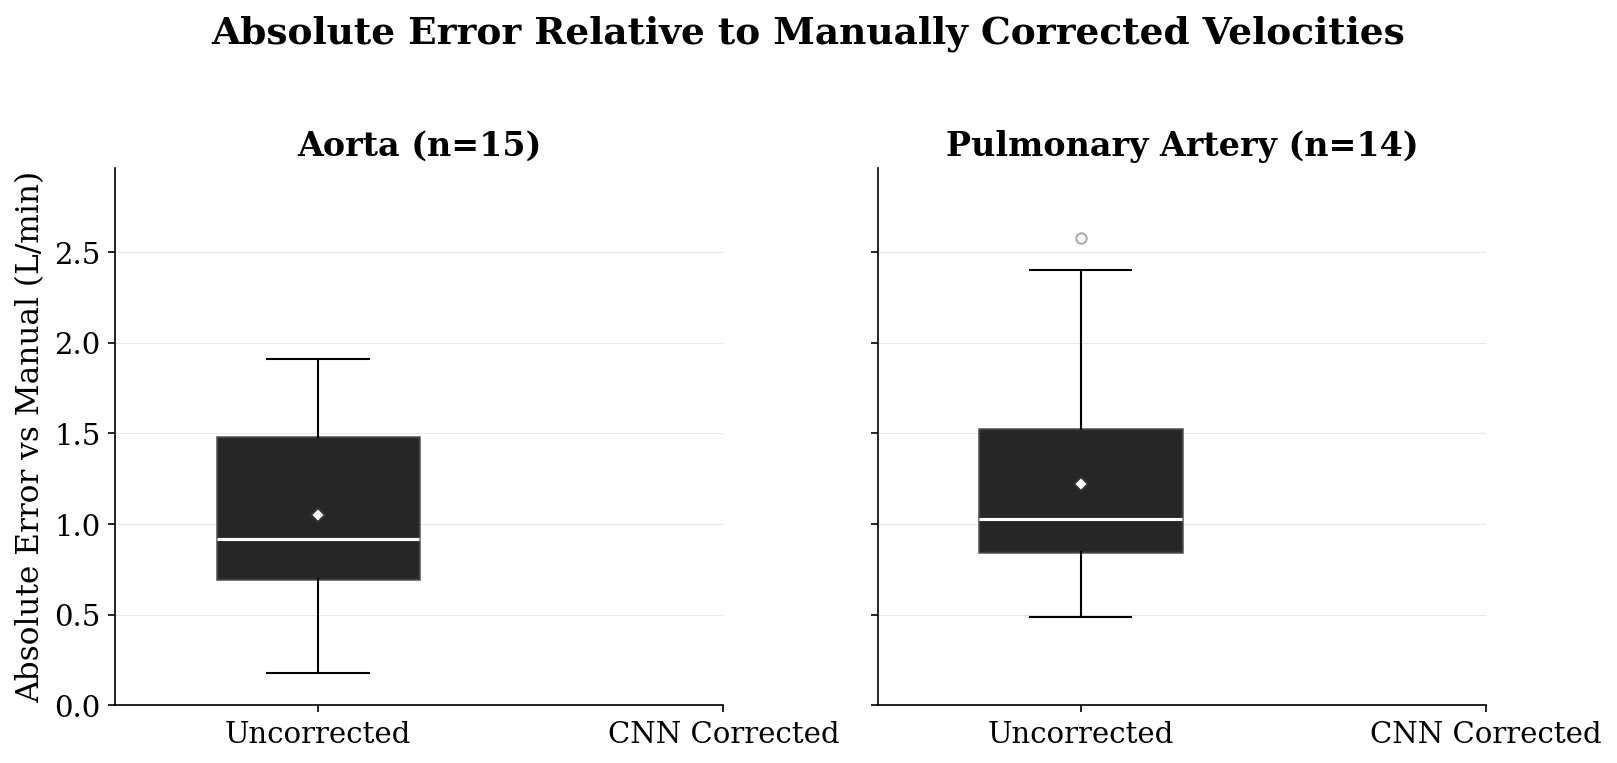

Saved: fig2a_abs_error_uncorrected.png


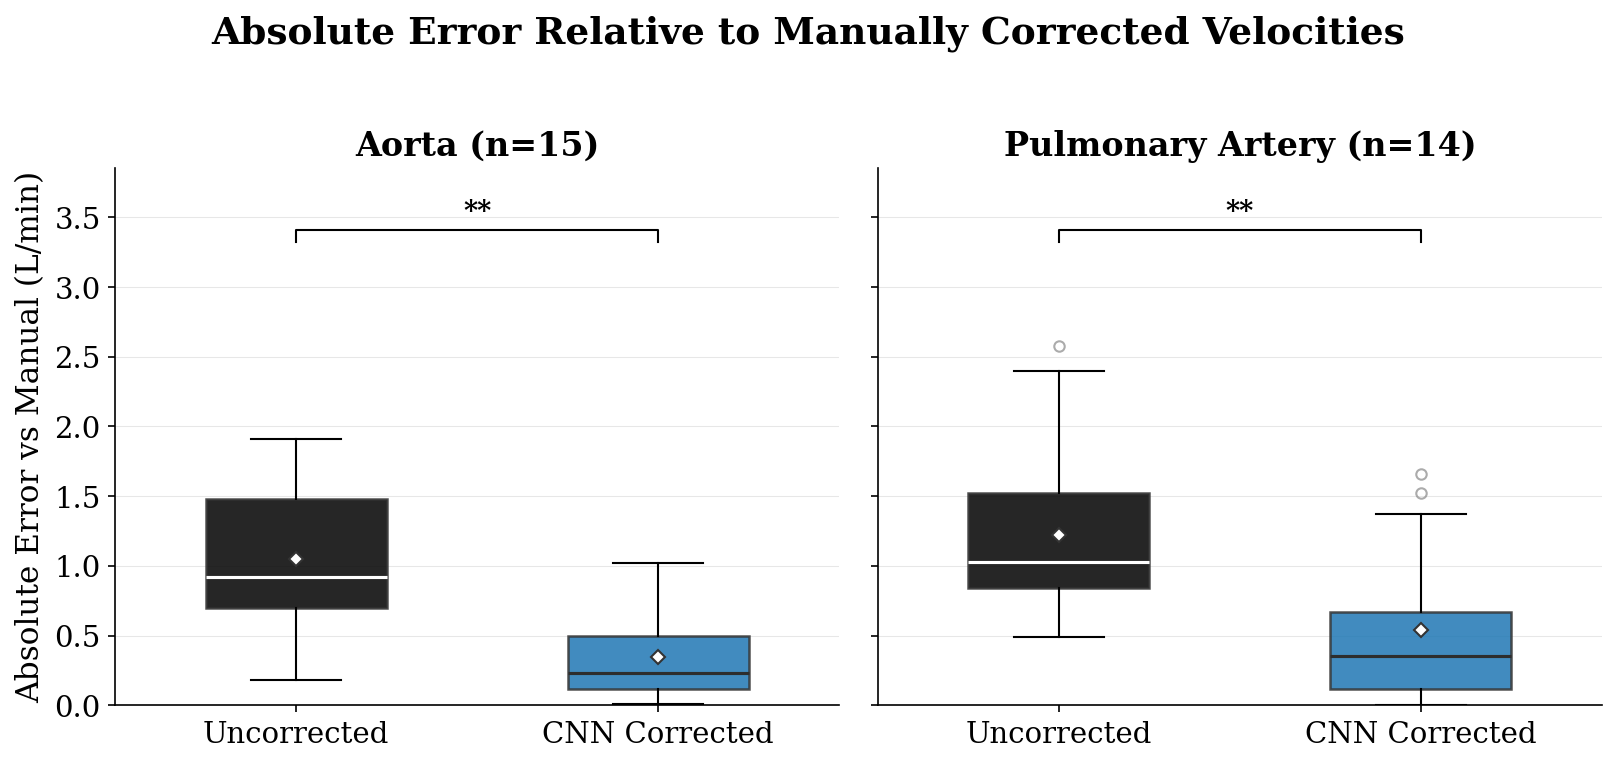

Saved: fig2a_abs_error_full.png


In [13]:
def _annotate_sig(ax, sig, x0, x1):
    if sig == "ns":
        return
    ylim = ax.get_ylim()
    span = ylim[1] - ylim[0]
    y = ylim[1] + span * 0.15
    h = span * 0.03
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color="black", linewidth=1.0)
    ax.text((x0 + x1) / 2, y + h * 0.3, sig, ha="center", va="bottom",
            fontsize=13, fontweight="bold")
    ax.set_ylim(ylim[0], y + h * 5)

# Precompute shared y-limit
all_ae = []
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["cnn_abs_error", "uncorrected_abs_error"])
    all_ae.extend(vp["uncorrected_abs_error"].values)
    all_ae.extend(vp["cnn_abs_error"].values)
YLIM = (0, max(all_ae) * 1.15)

STAGES = [
    ("uncorrected", True,  False, False),
    ("full",        True,  True,  True),
]

for stage_name, show_uncorr, show_cnn, show_sig in STAGES:
    fig, axes = plt.subplots(1, len(VESSELS), figsize=(5.5 * len(VESSELS), 5), sharey=True)

    for ax, vessel in zip(axes, VESSELS):
        vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(
            subset=["cnn_abs_error", "uncorrected_abs_error"])

        box_data = []
        box_positions = []
        box_colors = []

        if show_uncorr:
            box_data.append(vp["uncorrected_abs_error"])
            box_positions.append(0)
            box_colors.append("black")

        if show_cnn:
            box_data.append(vp["cnn_abs_error"])
            box_positions.append(1)
            box_colors.append(COLORS["cnn"])

        if box_data:
            bp = ax.boxplot(box_data, positions=box_positions, widths=0.5, **BOXPLOT_KW)
            color_boxes(bp, box_colors)
            for med, c in zip(bp["medians"], box_colors):
                if c == "black":
                    med.set_color("white")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Uncorrected", "CNN Corrected"])
        n_vessel = len(vp)
        ax.set_title(f"{VESSEL_LABELS[vessel]} (n={n_vessel})", fontweight="bold", fontsize=16)
        ax.set_ylim(YLIM)

        if show_sig:
            sr = stats_results[
                (stats_results["vessel"] == vessel) &
                (stats_results["comparison"] == "Error reduction (|Uncorr| \u2212 |CNN|)")
            ]
            if len(sr):
                sig = sr["wilcoxon_sig"].values[0]
                _annotate_sig(ax, sig, x0=0, x1=1)

    axes[0].set_ylabel("Absolute Error vs Manual (L/min)", fontsize=15)
    fig.suptitle("Absolute Error Relative to Manually Corrected Velocities",
                 fontsize=18, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig2a_abs_error_{stage_name}.png",
                bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: fig2a_abs_error_{stage_name}.png")

## Figure 3: Internal Consistency — Qp vs. Qs (Non-shunt Patients)

Scatter of (Qp − Qs) / Mean (%) vs. mean flow for Uncorrected, CNN Corrected, and Manually Corrected.
In patients without shunts, Qp ≈ Qs; reference line at zero.

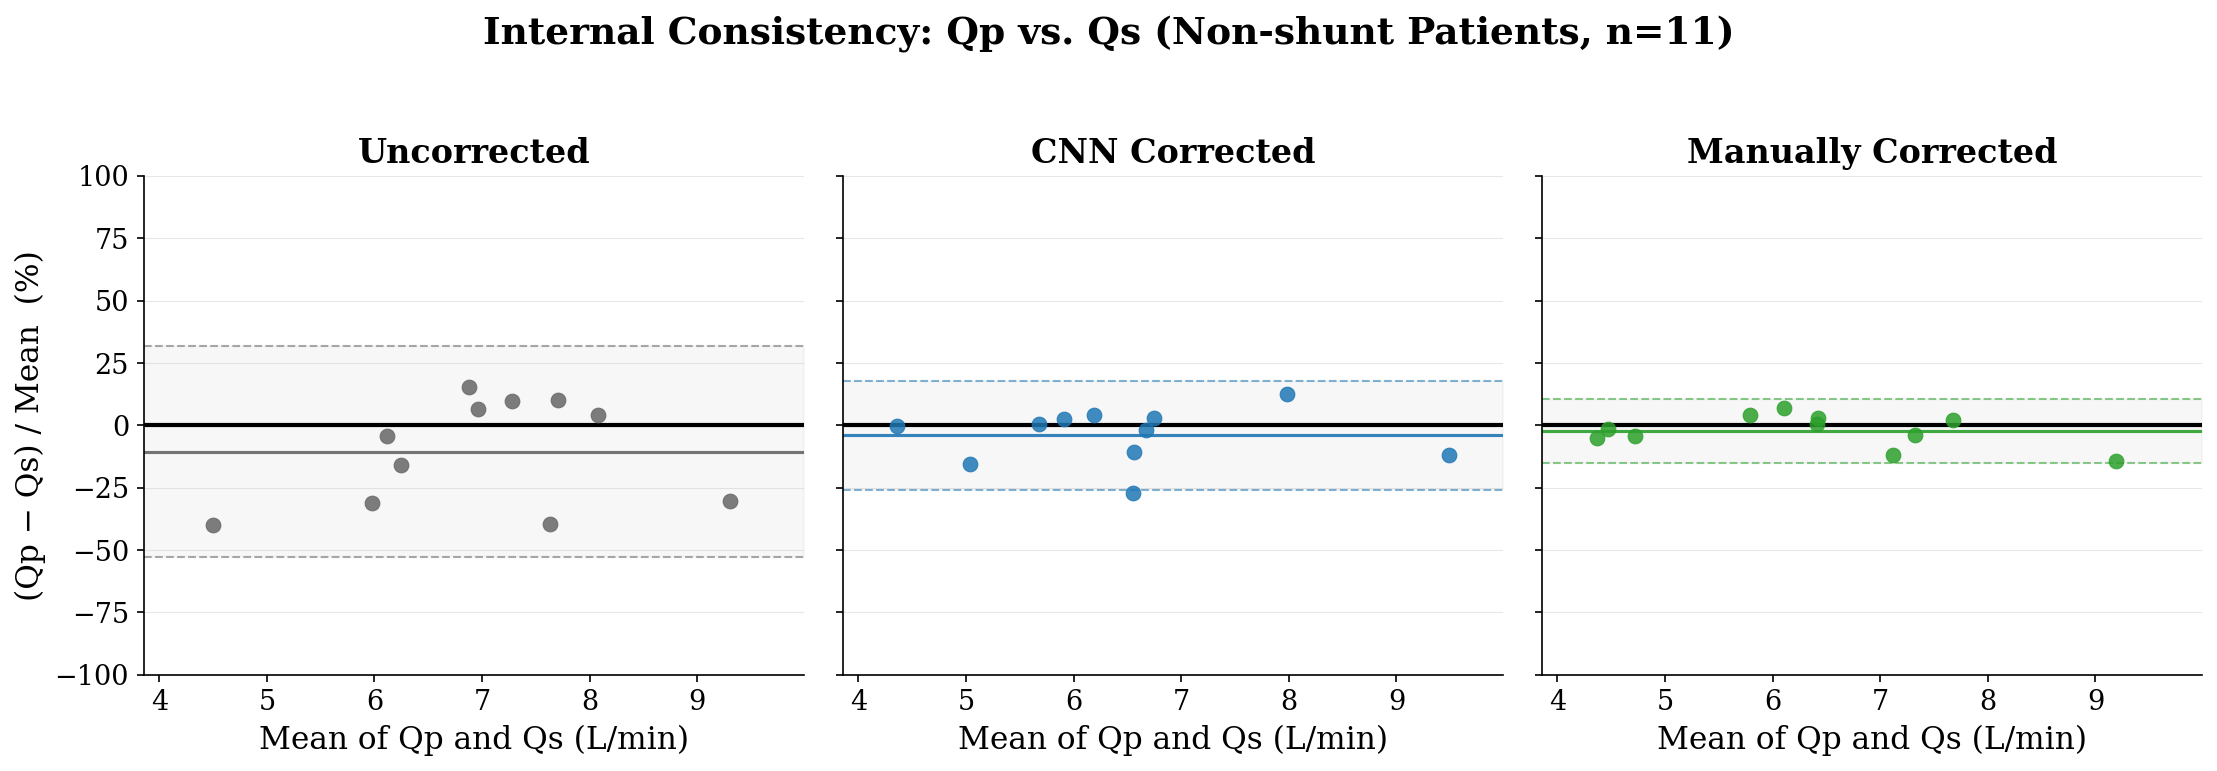

Saved: fig3_qpqs_internal_consistency.png


In [14]:
# Build qpqs from flow_pivot
ao_pivot = flow_pivot[flow_pivot["vessel"] == "Ao"][["patient", "manual", "cnn", "uncorrected"]].rename(
    columns={"manual": "ao_manual", "cnn": "ao_cnn", "uncorrected": "ao_uncorrected"}
)
pa_pivot = flow_pivot[flow_pivot["vessel"] == "PA"][["patient", "manual", "cnn", "uncorrected"]].rename(
    columns={"manual": "pa_manual", "cnn": "pa_cnn", "uncorrected": "pa_uncorrected"}
)
qpqs = ao_pivot.merge(pa_pivot, on="patient", how="inner")

SHUNT_PATIENTS = {"Golotag", "Tiepolem", "Oduskueb", "Suquepog"}
qpqs_ns = qpqs[~qpqs["patient"].isin(SHUNT_PATIENTS)].copy()

methods_ordered = ["uncorrected", "cnn", "manual"]
method_titles = {"manual": "Manually Corrected", "uncorrected": "Uncorrected", "cnn": "CNN Corrected"}
# Uncorrected = gray, CNN = blue (matches other figs); manual = green (distinct reference tone)
FIG3_POINT_COLORS = {
    "uncorrected": "#666666",
    "cnn": "#1f77b4",
    "manual": "#2ca02c",
}

all_means, all_pct_diffs = [], []
ba_ns_data = {}
for method in methods_ordered:
    ao_col, pa_col = f"ao_{method}", f"pa_{method}"
    sub = qpqs_ns[[ao_col, pa_col]].dropna()
    qs, qp = sub[ao_col].values, sub[pa_col].values
    mean_flow = (qp + qs) / 2
    pct_diff = (qp - qs) / mean_flow * 100
    ba_ns_data[method] = (mean_flow, pct_diff)
    all_means.extend(mean_flow)
    all_pct_diffs.extend(pct_diff)

x_lo, x_hi = min(all_means) - 0.5, max(all_means) + 0.5
y_lo, y_hi = -100, 100
n_ns = len(qpqs_ns)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, method in zip(axes, methods_ordered):
    mean_flow, pct_diff = ba_ns_data[method]
    pc = FIG3_POINT_COLORS[method]

    bias = pct_diff.mean()
    sd = pct_diff.std(ddof=1)
    loa_lo, loa_hi = bias - 1.96 * sd, bias + 1.96 * sd

    ax.scatter(mean_flow, pct_diff, c=pc, edgecolors=pc,
               linewidths=0.5, s=50, zorder=3, alpha=0.85)
    ax.axhline(bias, color=pc, linewidth=1.5, linestyle="-", alpha=0.9)
    ax.axhline(loa_lo, color=pc, linewidth=1, linestyle="--", alpha=0.55)
    ax.axhline(loa_hi, color=pc, linewidth=1, linestyle="--", alpha=0.55)
    ax.axhline(0, color="black", linewidth=2.0, alpha=1.0)
    ax.fill_between([x_lo, x_hi], loa_lo, loa_hi, color="#cccccc", alpha=0.15)

    ax.set_title(method_titles[method], fontweight="bold", fontsize=16)
    ax.set_xlabel("Mean of Qp and Qs (L/min)", fontsize=15)
    ax.tick_params(axis="both", labelsize=13)

axes[0].set_ylabel("(Qp − Qs) / Mean  (%)", fontsize=15)
axes[0].set_xlim(x_lo, x_hi)
axes[0].set_ylim(y_lo, y_hi)

fig.suptitle(f"Internal Consistency: Qp vs. Qs (Non-shunt Patients, n={n_ns})",
             fontsize=18, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_qpqs_internal_consistency.png",
            bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
print("Saved: fig3_qpqs_internal_consistency.png")

In [15]:
methods_ordered = ["uncorrected", "cnn", "manual"]
method_labels = {"uncorrected": "Uncorrected", "cnn": "CNN Corrected", "manual": "Manual"}

pct_diffs = {}
for method in methods_ordered:
    ao_col, pa_col = f"ao_{method}", f"pa_{method}"
    qs = qpqs_ns[ao_col].values
    qp = qpqs_ns[pa_col].values
    mean_flow = (qp + qs) / 2
    pct_diffs[method] = (qp - qs) / mean_flow * 100

# Per-patient table
pct_df = pd.DataFrame({
    "patient": qpqs_ns["patient"].values,
    "Uncorrected (%)": pct_diffs["uncorrected"],
    "CNN (%)": pct_diffs["cnn"],
    "Manual (%)": pct_diffs["manual"],
})
print("Per-patient (Qp − Qs) / Mean (%):")
print(pct_df.to_string(index=False))

# Summary statistics
print("\nVariance and SD of (Qp − Qs) / Mean (%):")
for method in methods_ordered:
    vals = pct_diffs[method]
    print(f"  {method_labels[method]:>15s}: var = {vals.var(ddof=1):.2f}, SD = {vals.std(ddof=1):.2f}, n = {len(vals)}")

# 3-group Brown-Forsythe test (scipy.stats.levene defaults to center='median')
from scipy.stats import levene, f as f_dist

W_all, p_all = levene(pct_diffs["uncorrected"], pct_diffs["cnn"], pct_diffs["manual"])
print(f"\n3-group Brown-Forsythe test: W = {W_all:.3f}, p = {p_all:.4f}")

# Pairwise Brown-Forsythe tests
print("\nPairwise Brown-Forsythe tests:")
pairs = [("uncorrected", "cnn"), ("uncorrected", "manual"), ("cnn", "manual")]
for m1, m2 in pairs:
    W, p = levene(pct_diffs[m1], pct_diffs[m2])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {method_labels[m1]:>15s} vs {method_labels[m2]:<15s}: W = {W:.3f}, p = {p:.4f} ({sig})")

# Classical F-tests for comparison
print("\nClassical F-tests (variance ratio):")
for m1, m2 in pairs:
    v1 = pct_diffs[m1].var(ddof=1)
    v2 = pct_diffs[m2].var(ddof=1)
    n = len(qpqs_ns)
    F = v1 / v2
    df1, df2 = n - 1, n - 1
    p_upper = 1 - f_dist.cdf(F, df1, df2)
    p_lower = f_dist.cdf(F, df1, df2)
    p = 2 * min(p_upper, p_lower)
    print(f"  {method_labels[m1]:>15s} vs {method_labels[m2]:<15s}: F = {F:.3f}, p = {p:.4f}")

Per-patient (Qp − Qs) / Mean (%):
  patient  Uncorrected (%)    CNN (%)  Manual (%)
Balboloop         9.759450  -1.799100    3.115265
  Biswifo       -31.103679   0.704225    4.145078
  Bomatog       -15.852682 -10.510282  -11.665495
   Detodu       -40.000000 -15.476190   -1.342282
 Diecudey       -39.580603 -27.175573   -3.825137
  Diepami         6.748026   2.535926   -4.237288
 Diequipi        -4.415372  -0.229621   -5.034325
 Dublafer        15.406977   4.200323    6.873977
  Dujomal       -30.413756 -12.012645  -14.246873
Grequafie         4.207921  12.648716    2.083333
 Gueshifa         9.993511   2.962963    0.467654

Variance and SD of (Qp − Qs) / Mean (%):
      Uncorrected: var = 461.81, SD = 21.49, n = 11
    CNN Corrected: var = 125.22, SD = 11.19, n = 11
           Manual: var = 42.66, SD = 6.53, n = 11

3-group Brown-Forsythe test: W = 7.728, p = 0.0020

Pairwise Brown-Forsythe tests:
      Uncorrected vs CNN Corrected  : W = 5.968, p = 0.0240 (*)
      Uncorrected vs M